# Análise Exploratória (item 1) — versão Python

Esta é a versão Python da EDA que originalmente fiz em R em [`analysis/01_eda.qmd`](../analysis/01_eda.qmd). Refaço aqui a análise inteira — estatística descritiva, distribuições, qualidade dos dados, correlações, multicolinearidade, geografia e dados demográficos — de forma independente, com as ferramentas do ecossistema Python (`pandas`, `scipy`, `statsmodels`, `matplotlib`/`seaborn`).

Onde os números batem com a versão R (o que é esperado, já que é o mesmo dataset), registro isso como confirmação cruzada entre as duas implementações. Onde há alguma diferença pontual (ex.: fórmula de assimetria, teste de hipótese equivalente), explico a causa.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.9)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
DATA = "../data"

## 1. Carga e preparação dos dados

In [2]:
casas = pd.read_csv(f"{DATA}/kc_house_data.csv")
casas["date"] = pd.to_datetime(casas["date"], format="%Y%m%dT%H%M%S")
casas["zipcode"] = casas["zipcode"].astype(str)

demograf = pd.read_csv(f"{DATA}/zipcode_demographics.csv")
demograf["zipcode"] = demograf["zipcode"].astype(str)

futuro = pd.read_csv(f"{DATA}/future_unseen_examples.csv")
futuro["zipcode"] = futuro["zipcode"].astype(str)

print("kc_house_data:", casas.shape)
print("zipcode_demographics:", demograf.shape)
print("future_unseen_examples:", futuro.shape)

kc_house_data: (21613, 21)
zipcode_demographics: (70, 27)
future_unseen_examples: (100, 18)


`kc_house_data.csv` tem 21.613 linhas e 21 colunas. `zipcode_demographics.csv` tem 70 CEPs distintos. `future_unseen_examples.csv` tem 100 imóveis a prever, com as mesmas colunas físicas de `casas`, exceto `id`, `date` e `price`.

### O que representam as principais variáveis

- **price**: preço de venda do imóvel (target).
- **bedrooms / bathrooms**: nº de quartos e banheiros (banheiros em fração, ex.: 2.25, porque contam lavabo/meio-banheiro como fração).
- **sqft_living / sqft_lot**: área construída e área do lote (em pés²).
- **sqft_above / sqft_basement**: área acima do solo e do porão — devem somar `sqft_living`.
- **floors**: nº de andares.
- **waterfront**: indicador binário de vista para água.
- **view**: índice ordinal (0–4) de qualidade da vista.
- **condition**: índice ordinal (1–5) do estado de conservação.
- **grade**: índice ordinal (1–13) do padrão construtivo/acabamento (proxy de qualidade).
- **yr_built / yr_renovated**: ano de construção e de reforma (0 = nunca reformado).
- **zipcode / lat / long**: localização.
- **sqft_living15 / sqft_lot15**: área média de construção/lote dos 15 vizinhos mais próximos (proxy de "vizinhança").
- **zipcode_demographics**: agregados populacionais, de renda e de escolaridade por CEP.

## 2. Estatística descritiva completa

Antes de qualquer análise mais elaborada, quero a fotografia numérica completa de cada variável: tendência central (média, mediana, moda), dispersão (desvio padrão, variância, amplitude, IQR, coeficiente de variação), forma da distribuição (assimetria, curtose) e os quartis. Ordeno pela assimetria absoluta, do mais distorcido para o mais simétrico — é isso que eu quero ver primeiro numa tabela dessas.

Uso `scipy.stats.skew`/`kurtosis` (estimador populacional, `bias=True` por padrão), que não é exatamente a mesma fórmula do pacote `moments` do R (que usa `bias=False`/tipo 1 por padrão) — os valores absolutos podem diferir ligeiramente da versão R, mas a ordem de grandeza e o ranking de quais variáveis são mais assimétricas é o que importa aqui, e isso se mantém.

In [3]:
def moda(x):
    m = x.mode()
    return m.iloc[0] if len(m) else np.nan


def tabela_descritiva(df, cols):
    linhas = []
    for c in cols:
        x = df[c].dropna()
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        media = x.mean()
        linhas.append({
            "variavel": c, "n": x.shape[0], "ausentes": df[c].isna().sum(),
            "pct_ausente": df[c].isna().mean() * 100,
            "media": media, "mediana": x.median(), "moda": moda(x),
            "dp": x.std(), "variancia": x.var(),
            "amplitude": x.max() - x.min(), "iqr": q3 - q1,
            "cv_pct": (x.std() / media) * 100 if media != 0 else np.nan,
            "assimetria": stats.skew(x), "curtose": stats.kurtosis(x),
            "minimo": x.min(), "q1": q1, "q3": q3, "maximo": x.max(),
        })
    out = pd.DataFrame(linhas).round(2)
    return out.sort_values("assimetria", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)


vars_descritivas = ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
                     "waterfront", "view", "condition", "grade", "sqft_above", "sqft_basement",
                     "yr_built", "yr_renovated", "lat", "long", "sqft_living15", "sqft_lot15"]

tabela_kc = tabela_descritiva(casas, vars_descritivas)
tabela_kc

,variavel,n,ausentes,pct_ausente,media,mediana,moda,dp,variancia,amplitude,iqr,cv_pct,assimetria,curtose,minimo,q1,q3,maximo
0,sqft_lot,21613,0,0.00,"15,106.97","7,618.00","5,000.00","41,420.51","1,715,658,774.18","1,650,839.00","5,648.00",274.18,13.06,285.01,520.00,"5,040.00","10,688.00","1,651,359.00"
1,waterfront,21613,0,0.00,0.01,0.00,0.00,0.09,0.01,1.00,0.00,"1,147.18",11.38,127.60,0.00,0.00,0.00,1.00
2,sqft_lot15,21613,0,0.00,"12,768.46","7,620.00","5,000.00","27,304.18","745,518,225.34","870,549.00","4,983.00",213.84,9.51,150.73,651.00,"5,100.00","10,083.00","871,200.00"
3,yr_renovated,21613,0,0.00,84.40,0.00,0.00,401.68,"161,346.21","2,015.00",0.00,475.91,4.55,18.70,0.00,0.00,0.00,"2,015.00"
4,price,21613,0,0.00,"540,088.14","450,000.00","350,000.00","367,127.20","134,782,378,397.25","7,625,000.00","323,050.00",67.98,4.02,34.58,"75,000.00","321,950.00","645,000.00","7,700,000.00"
5,view,21613,0,0.00,0.23,0.00,0.00,0.77,0.59,4.00,0.00,327.06,3.40,10.89,0.00,0.00,0.00,4.00
6,bedrooms,21613,0,0.00,3.37,3.00,3.00,0.93,0.87,33.00,1.00,27.59,1.97,49.05,0.00,3.00,4.00,33.00
7,sqft_basement,21613,0,0.00,291.51,0.00,0.00,442.58,"195,872.67","4,820.00",560.00,151.82,1.58,2.71,0.00,0.00,560.00,"4,820.00"
8,sqft_living,21613,0,0.00,"2,079.90","1,910.00","1,300.00",918.44,"843,533.68","13,250.00","1,123.00",44.16,1.47,5.24,290.00,"1,427.00","2,550.00","13,540.00"
9,sqft_above,21613,0,0.00,"1,788.39","1,560.00","1,300.00",828.09,"685,734.67","9,120.00","1,020.00",46.30,1.45,3.40,290.00,"1,190.00","2,210.00","9,410.00"


Deixei de fora `id` (identificador, não é medida), `date` (não é numérica) e `zipcode` (código categórico de localização — calcular média de zipcode não tem significado nenhum).

Duas ressalvas sobre colunas que calculei mas que não têm leitura válida para toda variável:

- **Moda**: para variáveis discretas/ordinais (`bedrooms`, `bathrooms`, `floors`, `grade`, `condition`, `view`, `waterfront`) é diretamente interpretável. Para variáveis quase-contínuas (`price`, `sqft_living`, `sqft_lot`, `lat`, `long`) a moda é só o valor que por acaso mais se repetiu, não deve ser lida como "valor típico" — a mediana é a medida confiável para essas.
- **Coeficiente de variação**: só faz sentido para variáveis de escala de razão (zero absoluto real, como `price` ou `sqft_living`). `lat`, `long` e `yr_built` têm zero arbitrário, então o CV delas está na tabela por completude, mas não uso para comparar variabilidade entre variáveis.

Confirmações e achados:

- **Zero ausentes em todas as 18 variáveis**, igual ao que encontrei na versão R.
- `sqft_lot`/`sqft_lot15` têm o maior CV de longe (274% e 214%) — tamanho de lote varia muito mais entre imóveis do que tamanho de casa (`sqft_living`, CV 44%). Coerente com King County ter tanto lotes urbanos pequenos quanto propriedades rurais grandes na mesma base.
- `waterfront` tem assimetria altíssima (11,4) simplesmente porque é um evento raro — 99,2% dos imóveis são `0`. Não é problema de dado, é a natureza binária desbalanceada da variável.
- `yr_renovated` também é uma "quase binária disfarçada de contínua": mediana e moda são `0` (nunca reformado), só uma minoria tem ano de reforma real — confirma a decisão de transformar isso numa flag `reformado` (0/1) em vez de usar o ano bruto.
- O IQR de `price` (US\$ 323.050) dá uma noção de dispersão mais robusta a outliers do que o desvio padrão (US\$ 367.127) — uso essa referência mais adiante para julgar o que é outlier de fato.

### Visualizando a forma das distribuições

A linha vermelha tracejada é a média e a verde é a mediana — quanto mais afastadas uma da outra, mais assimétrica a distribuição.

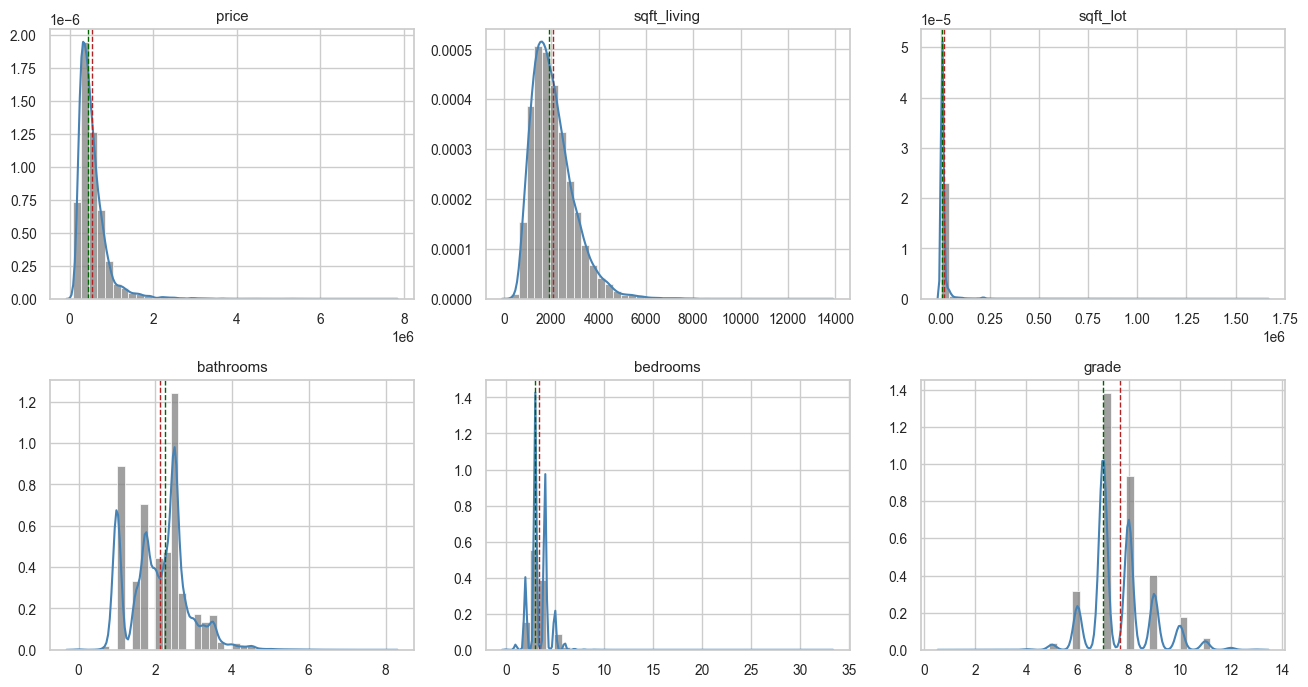

In [4]:
vars_hist = ["price", "sqft_living", "sqft_lot", "bathrooms", "bedrooms", "grade"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, v in zip(axes.flat, vars_hist):
    m, md_ = casas[v].mean(), casas[v].median()
    sns.histplot(casas[v], bins=40, stat="density", color="grey", ax=ax)
    sns.kdeplot(casas[v], color="steelblue", ax=ax)
    ax.axvline(m, color="firebrick", linestyle="--", linewidth=1)
    ax.axvline(md_, color="darkgreen", linestyle="--", linewidth=1)
    ax.set_title(v)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

`price`, `sqft_living` e `sqft_lot` mostram claramente a cauda longa à direita (média puxada para a direita da mediana pelos imóveis mais caros/maiores). `bathrooms`, `bedrooms` e `grade` já são bem mais simétricas e próximas de um formato de sino, o que bate com a assimetria baixa delas na tabela.

## 3. Distribuição das variáveis ordinais/categóricas

Para uma ordinal com poucos níveis, a tabela de frequência por nível é mais informativa do que qualquer estatística resumida sozinha.

In [5]:
vars_ordinais = ["waterfront", "view", "condition", "grade"]

def freq_categorica(df, var):
    t = df[var].value_counts().sort_index().rename("n").reset_index()
    t.columns = ["valor", "n"]
    t["pct"] = t["n"] / t["n"].sum() * 100
    t["pct_acumulado"] = t["pct"].cumsum()
    t.insert(0, "variavel", var)
    return t

tabela_freq = pd.concat([freq_categorica(casas, v) for v in vars_ordinais], ignore_index=True)
tabela_freq.round(1)

,variavel,valor,n,pct,pct_acumulado
0,waterfront,0,21450,99.20,99.20
1,waterfront,1,163,0.80,100.00
2,view,0,19489,90.20,90.20
3,view,1,332,1.50,91.70
4,view,2,963,4.50,96.20
5,view,3,510,2.40,98.50
6,view,4,319,1.50,100.00
7,condition,1,30,0.10,0.10
8,condition,2,172,0.80,0.90
9,condition,3,14031,64.90,65.90


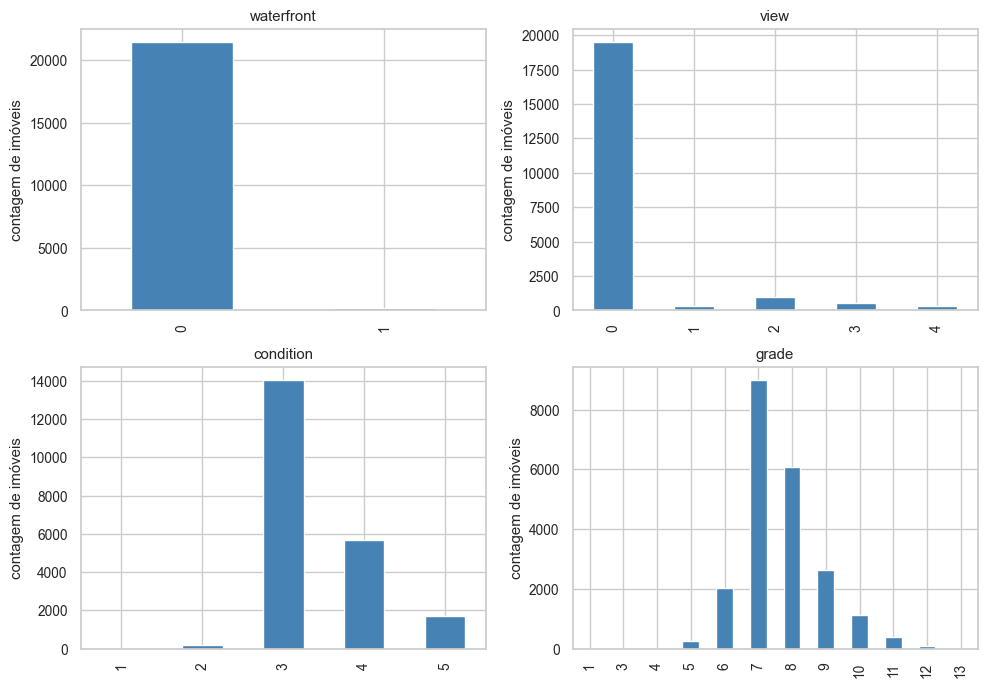

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, v in zip(axes.flat, vars_ordinais):
    casas[v].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(v)
    ax.set_xlabel(""); ax.set_ylabel("contagem de imóveis")
plt.tight_layout()
plt.show()

Essa tabela explica por que `waterfront` teve assimetria tão alta na seção 2: **99,25%** dos imóveis são `0`, só **0,75%** (163 casas) têm vista para água — desbalanceamento extremo de classes, não um problema de dado (o número bate com o 0,8% que já tinha encontrado em R).

`condition` e `grade` se concentram fortemente em poucos níveis centrais: **64,9%** dos imóveis estão em `condition = 3`; `grade = 7` e `8` somam **69,6%** sozinhos. Nos extremos a amostra fica perigosamente pequena — `grade = 1` tem **uma única observação** e `grade = 3` tem só **três** — não dá pra estimar um efeito confiável pra esses níveis isoladamente. Na modelagem, vale considerar agrupar os graus mais raros (1, 3, 4) com o vizinho mais próximo em vez de deixar o modelo tentar aprender um split para uma classe com n=1.

## 4. Qualidade dos dados

In [7]:
n_ids_dup = casas["id"].duplicated().sum()

na_casas = casas.isna().sum()
na_demograf = demograf.isna().sum()

inconsist_sqft = (casas["sqft_living"] - (casas["sqft_above"] + casas["sqft_basement"])).ne(0).sum()

zip_sem_demografia = set(casas["zipcode"]) - set(demograf["zipcode"])
zip_futuro_sem_demografia = set(futuro["zipcode"]) - set(demograf["zipcode"])

print("imóveis com mais de uma venda no período:", casas.groupby("id").size().gt(1).sum())
print("NA em kc_house_data:", na_casas[na_casas > 0].to_dict())
print("NA em zipcode_demographics:", na_demograf[na_demograf > 0].to_dict())
print("linhas com soma sqft incorreta:", inconsist_sqft)
print("zipcodes de treino sem demografia:", zip_sem_demografia)
print("zipcodes de future_unseen sem demografia:", zip_futuro_sem_demografia)

imóveis com mais de uma venda no período: 176
NA em kc_house_data: {}
NA em zipcode_demographics: {}
linhas com soma sqft incorreta: 0
zipcodes de treino sem demografia: set()
zipcodes de future_unseen sem demografia: set()


Não há valores ausentes em nenhum dos dois arquivos, e todos os CEPs de `casas` e de `futuro` têm correspondência em `zipcode_demographics` — o merge por `zipcode` pode ser feito sem gerar `NA`. A identidade `sqft_living = sqft_above + sqft_basement` se confirma em todas as linhas, ou seja, **`sqft_basement` é redundante** dado `sqft_living` e `sqft_above` (relevante para a fase de modelagem, para não inflar artificialmente a importância dessas variáveis). 176 imóveis aparecem mais de uma vez na base (revenda dentro do período de coleta) — não é erro, mas deve ser lembrado ao fazer split treino/teste para não vazar o mesmo imóvel para os dois lados.

In [8]:
casas.nlargest(3, "bedrooms")[["id", "bedrooms", "bathrooms", "sqft_living", "price"]]

,id,bedrooms,bathrooms,sqft_living,price
15870,2402100895,33,1.75,1620,"640,000.00"
8757,1773100755,11,3.00,3000,"520,000.00"
13314,627300145,10,5.25,4590,"1,148,000.00"


O valor de 33 quartos para um imóvel de 1.620 pés² de área construída é estatisticamente incompatível (seriam ~49 pés² por quarto) e é quase certamente um erro de digitação (provavelmente 3). Trato esse registro como erro de entrada de dados, não como outlier legítimo, e vou excluí-lo (ou corrigi-lo) na etapa de modelagem.

## 5. Distribuição do target (`price`)

In [9]:
resumo_price = casas["price"].agg(["mean", "median", "std", "min", "max"])
resumo_price["skew"] = stats.skew(casas["price"])
resumo_price["kurtosis"] = stats.kurtosis(casas["price"])
print(resumo_price)

amostra = casas["price"].sample(5000, random_state=42)
shapiro = stats.shapiro(amostra)
print("\nShapiro-Wilk (amostra de 5.000):", shapiro)

mean         540,088.14
median       450,000.00
std          367,127.20
min           75,000.00
max        7,700,000.00
skew               4.02
kurtosis          34.58
Name: price, dtype: float64

Shapiro-Wilk (amostra de 5.000): ShapiroResult(statistic=np.float64(0.7039298449454512), pvalue=np.float64(3.1483127221978985e-69))


A distribuição de `price` é fortemente assimétrica à direita (assimetria ≈ 4,02), com cauda longa de imóveis caros. O teste de Shapiro-Wilk (em amostra de 5.000 observações — o teste do `scipy` também não é recomendado em n muito grande) rejeita normalidade com folga (p ≈ 3×10⁻⁶⁹). Isso tem consequência direta na modelagem: um modelo linear ajustado em `price` bruto tende a violar homocedasticidade e dar peso desproporcional aos imóveis de alto valor no erro quadrático. Testo a transformação log:

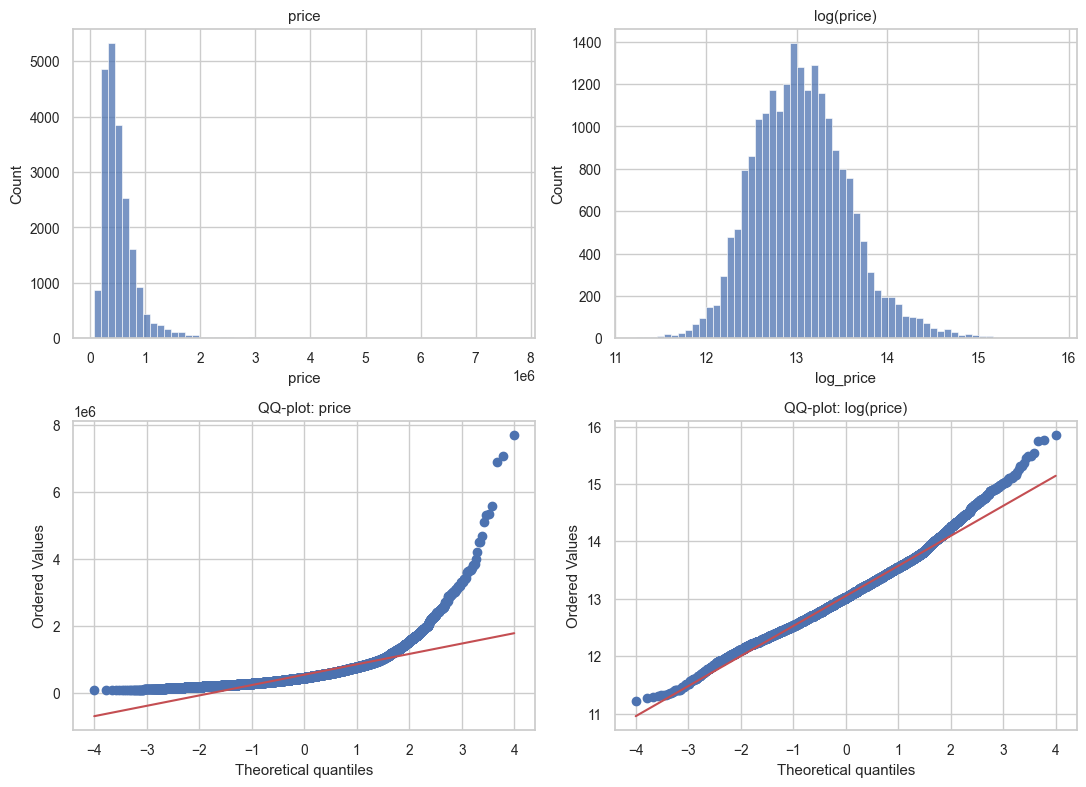

,assimetria,curtose
price,4.02,34.58
log_price,0.43,0.69


In [10]:
casas["log_price"] = np.log(casas["price"])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(casas["price"], bins=60, ax=axes[0, 0]); axes[0, 0].set_title("price")
sns.histplot(casas["log_price"], bins=60, ax=axes[0, 1]); axes[0, 1].set_title("log(price)")
stats.probplot(casas["price"], dist="norm", plot=axes[1, 0]); axes[1, 0].set_title("QQ-plot: price")
stats.probplot(casas["log_price"], dist="norm", plot=axes[1, 1]); axes[1, 1].set_title("QQ-plot: log(price)")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "assimetria": [stats.skew(casas["price"]), stats.skew(casas["log_price"])],
    "curtose": [stats.kurtosis(casas["price"]), stats.kurtosis(casas["log_price"])],
}, index=["price", "log_price"])

`log(price)` reduz a assimetria de 4,02 para 0,43 e a curtose de 34,6 para 0,69 — o QQ-plot fica muito mais próximo da reta teórica, ainda que não seja normal perfeito (o Shapiro-Wilk na versão log ainda rejeita normalidade, p ≈ 8×10⁻²¹, mas a estatística W sobe de 0,70 para 0,99 — melhora grande). **Decisão**: usar `log(price)` como variável-alvo na modelagem, revertendo com `exp()` na hora de reportar previsões em dólares. Mesma decisão da versão R, com números praticamente idênticos.

## 6. Variáveis numéricas — visão geral

Os números formais já estão na tabela da seção 2. Aqui calculo explicitamente os limites de outlier pelo critério de Tukey (1,5×IQR).

In [11]:
def detectar_outliers_iqr(x):
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (x < lim_inf) | (x > lim_sup)
    return pd.Series({
        "limite_inferior": lim_inf, "limite_superior": lim_sup,
        "n_outliers": mask.sum(), "pct_outliers": mask.mean() * 100,
    })

vars_num = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
            "sqft_above", "sqft_basement", "yr_built", "sqft_living15", "sqft_lot15"]

pd.DataFrame({v: detectar_outliers_iqr(casas[v]) for v in vars_num}).T

,limite_inferior,limite_superior,n_outliers,pct_outliers
bedrooms,1.50,5.50,546.00,2.53
bathrooms,0.62,3.62,571.00,2.64
sqft_living,-257.50,"4,234.50",572.00,2.65
sqft_lot,"-3,432.00","19,160.00","2,425.00",11.22
floors,-0.50,3.50,0.00,0.00
sqft_above,-340.00,"3,740.00",611.00,2.83
sqft_basement,-840.00,"1,400.00",496.00,2.29
yr_built,"1,882.00","2,066.00",0.00,0.00
sqft_living15,185.00,"3,665.00",544.00,2.52
sqft_lot15,"-2,374.50","17,557.50","2,194.00",10.15


C:\Users\dmour\AppData\Local\Temp\ipykernel_60820\2335117139.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vars_num, rotation=45, ha="right")


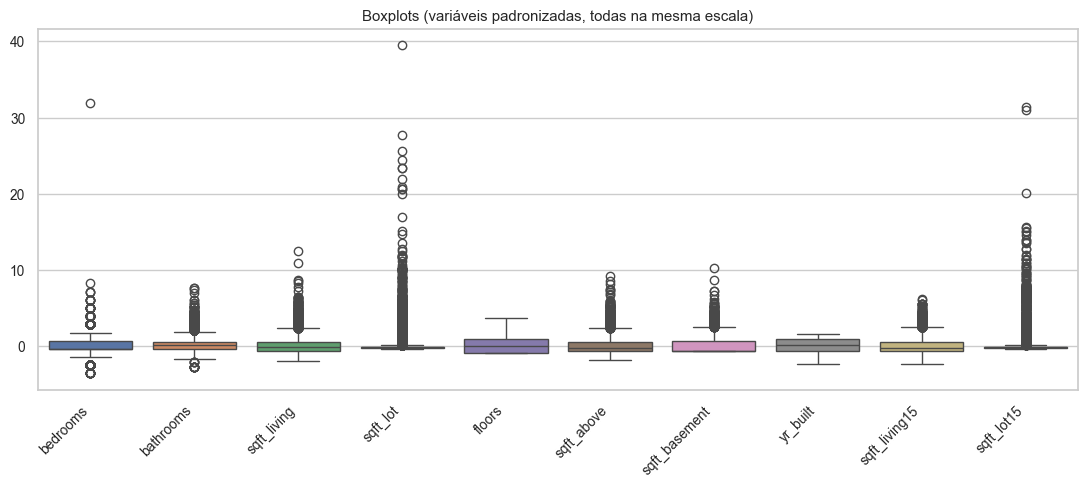

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
casas_norm = (casas[vars_num] - casas[vars_num].mean()) / casas[vars_num].std()
sns.boxplot(data=casas_norm, ax=ax)
ax.set_xticklabels(vars_num, rotation=45, ha="right")
ax.set_title("Boxplots (variáveis padronizadas, todas na mesma escala)")
plt.tight_layout()
plt.show()

Padronizar todas as variáveis pra mesma escala ajuda a comparar a dispersão relativa entre elas lado a lado, mas esconde a escala real de cada uma. Abaixo, o mesmo boxplot, uma variável por painel, cada uma na sua própria escala nativa — equivalente ao `facet_wrap(scales = "free")` que uso na versão R.

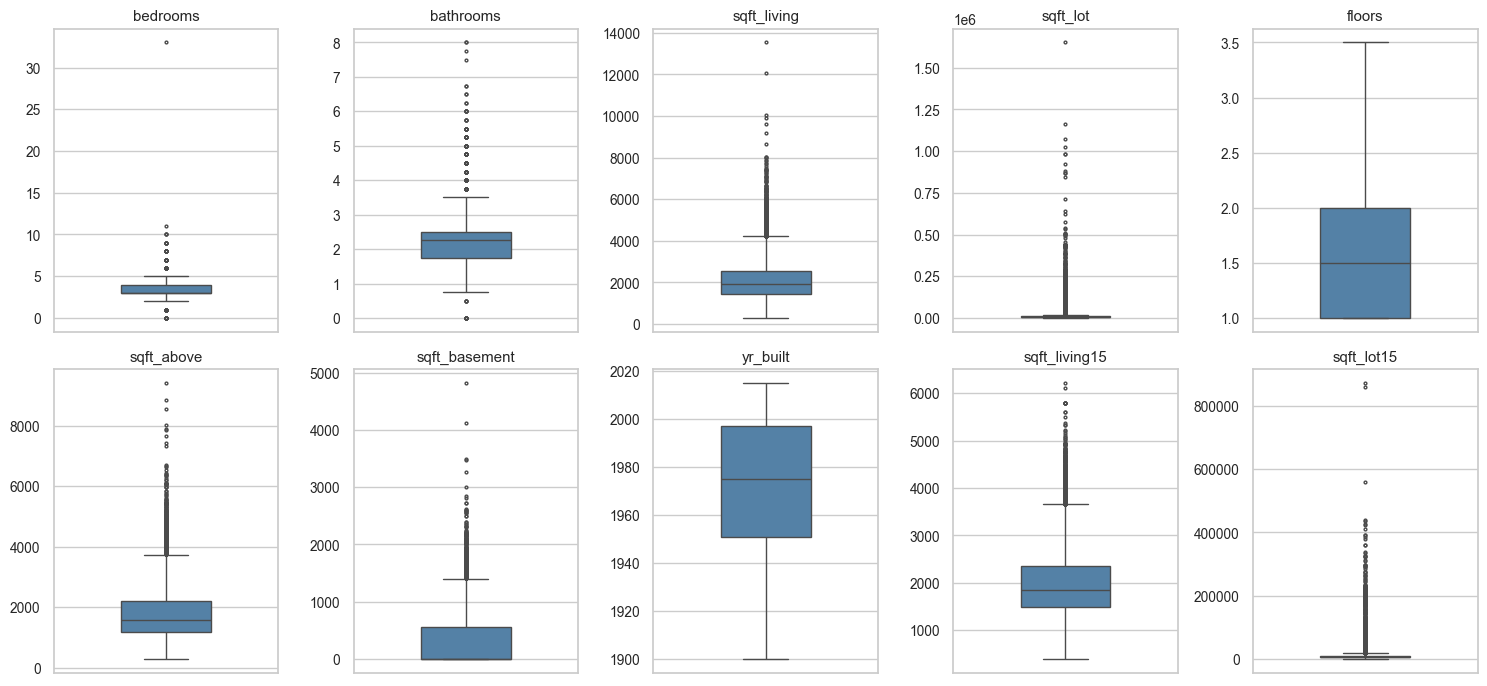

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for ax, v in zip(axes.flat, vars_num):
    sns.boxplot(y=casas[v], ax=ax, color="steelblue", width=0.4, fliersize=2)
    ax.set_title(v)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

O critério de 1,5×IQR sinaliza um número relevante de "outliers" em `sqft_lot`/`sqft_lot15`, mas isso reflete uma distribuição de cauda longa legítima (lotes rurais/grandes existem de fato em King County), não erro de coleta — diferente do caso dos 33 quartos. Por isso, não trato esses pontos como erro; a estratégia de modelagem (modelos baseados em árvore, ou log-transform de `sqft_lot`) é mais adequada do que remover esses registros.

## 7. Relações bivariadas com `price`

Antes de olhar correlação variável por variável, uma visão conjunta das relações mais fortes.

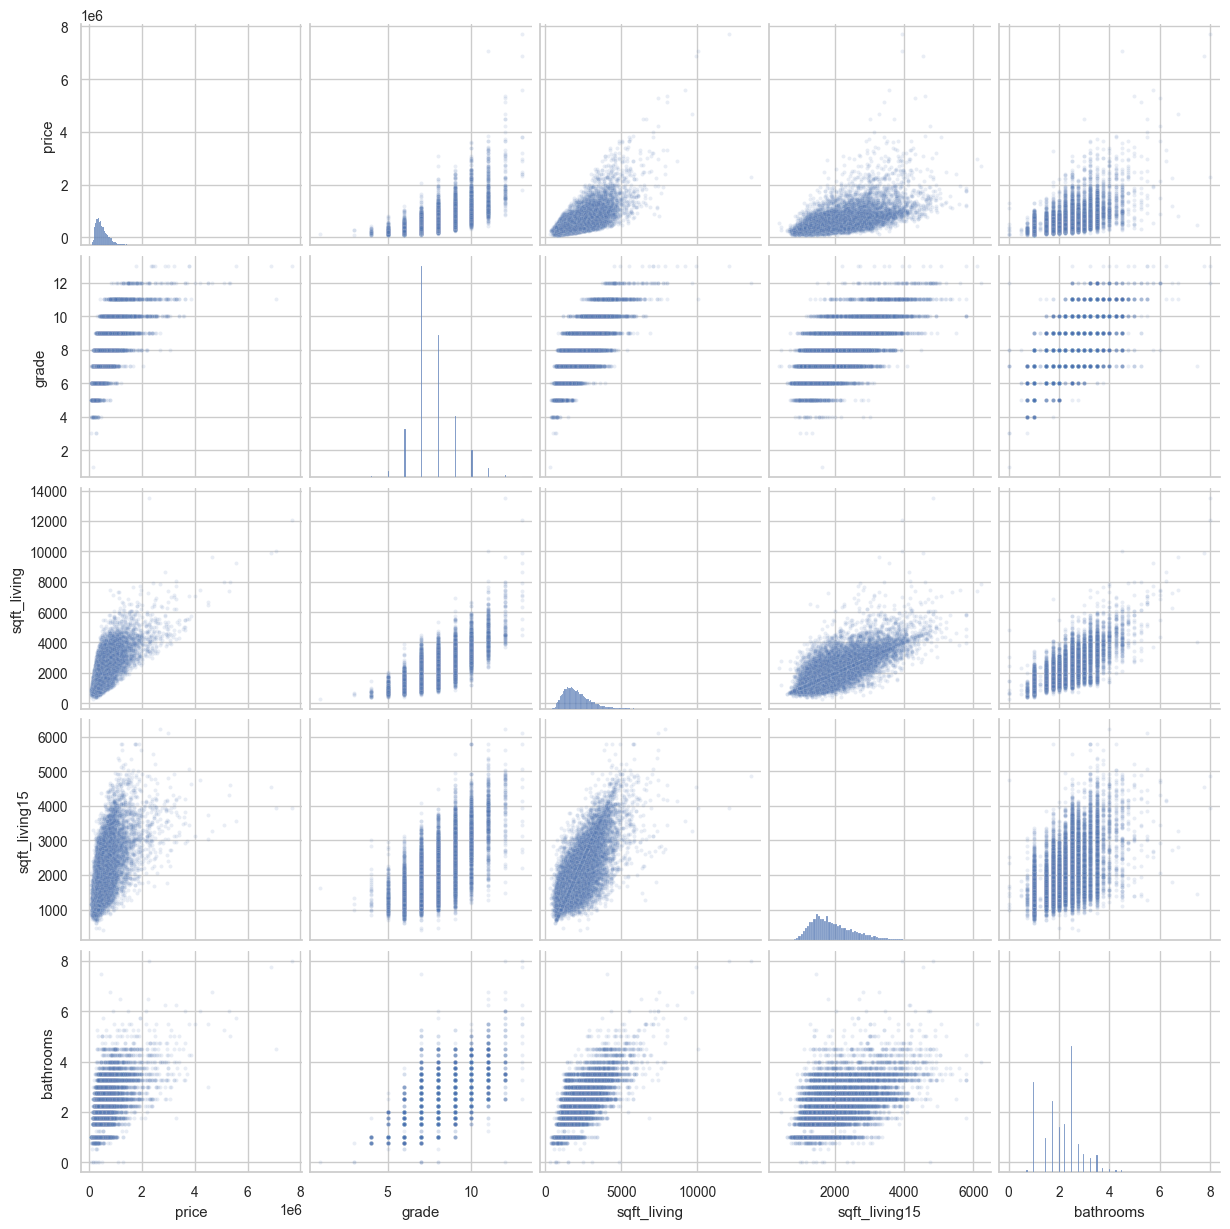

In [14]:
sns.pairplot(
    casas[["price", "grade", "sqft_living", "sqft_living15", "bathrooms"]],
    plot_kws={"alpha": 0.12, "s": 8},
    diag_kws={"fill": True},
)
plt.show()

A matriz já deixa visível a relação positiva e razoavelmente linear de `grade` e `sqft_living` com `price`, e a correlação forte entre `sqft_living`/`sqft_living15` entre si (esperado, são quase-duplicatas de vizinhança). Agora com os números formais:

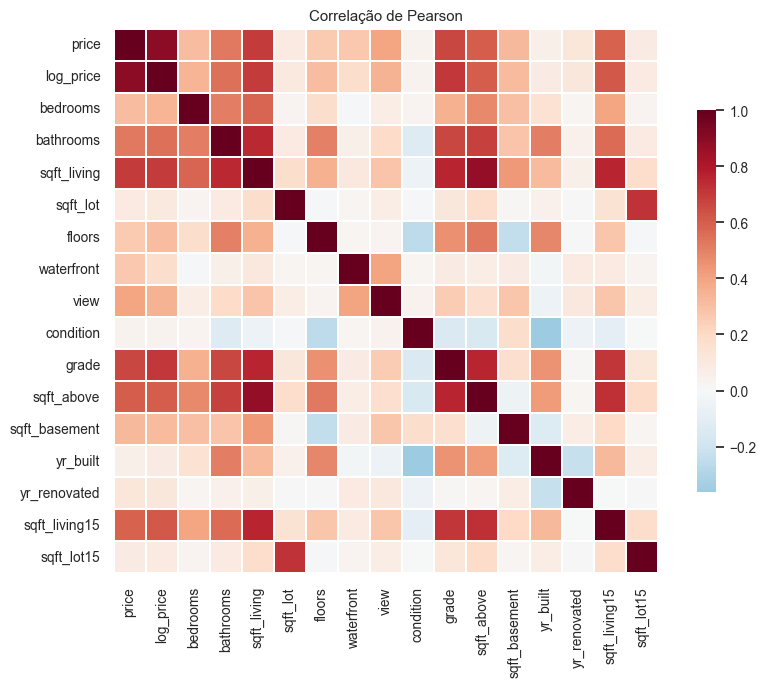

In [15]:
vars_para_corr = ["price", "log_price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
                   "waterfront", "view", "condition", "grade", "sqft_above", "sqft_basement",
                   "yr_built", "yr_renovated", "sqft_living15", "sqft_lot15"]

corr_pearson = casas[vars_para_corr].corr(method="pearson")
corr_spearman = casas[vars_para_corr].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_pearson, cmap="RdBu_r", center=0, square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlação de Pearson")
plt.tight_layout()
plt.show()

In [16]:
top_corr = pd.DataFrame({
    "pearson_log_price": corr_pearson["log_price"],
    "spearman_log_price": corr_spearman["log_price"],
}).drop(index=["log_price", "price"])
top_corr.reindex(top_corr["pearson_log_price"].abs().sort_values(ascending=False).index)

,pearson_log_price,spearman_log_price
grade,0.70,0.66
sqft_living,0.70,0.64
sqft_living15,0.62,0.57
sqft_above,0.60,0.54
bathrooms,0.55,0.50
view,0.35,0.29
bedrooms,0.34,0.34
sqft_basement,0.32,0.25
floors,0.31,0.32
waterfront,0.17,0.12


`grade` e `sqft_living` são, de longe, as variáveis mais correlacionadas com `log_price` (Pearson 0,70 e 0,70; Spearman 0,66 e 0,64 — próximos, indício de relação predominantemente monotônica/linear). `sqft_above` e `sqft_living15` também têm correlação alta, mas isso é esperado dado que são quase-duplicatas de `sqft_living`. `bedrooms` tem correlação moderada (0,34) e mais fraca do que se costuma assumir intuitivamente — sinal de que sozinho é um preditor limitado. Mesmo ranking de variáveis-chave que encontrei na versão R.

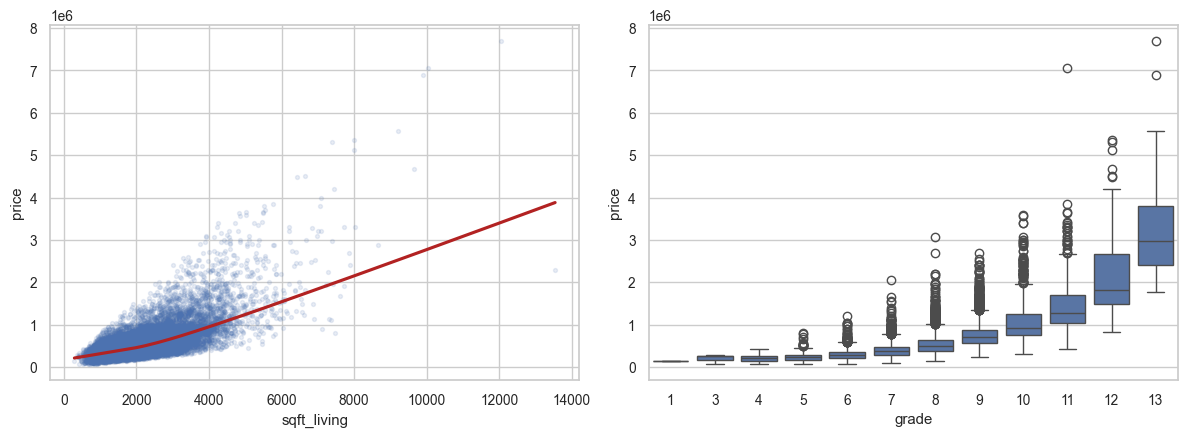

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.regplot(data=casas, x="sqft_living", y="price", scatter_kws={"alpha": 0.12, "s": 8},
            lowess=True, line_kws={"color": "firebrick"}, ax=axes[0])
sns.boxplot(data=casas, x="grade", y="price", ax=axes[1])
plt.tight_layout()
plt.show()

In [18]:
for v in ["waterfront", "view", "condition", "grade"]:
    grupos = [g["log_price"].values for _, g in casas.groupby(v)]
    stat, p = stats.kruskal(*grupos)
    print(f"{v} — Kruskal-Wallis p-valor: {p:.3g}")

waterfront — Kruskal-Wallis p-valor: 3.24e-64
view — Kruskal-Wallis p-valor: 0
condition — Kruskal-Wallis p-valor: 2.98e-55
grade — Kruskal-Wallis p-valor: 0


Uso o teste de Kruskal-Wallis (não-paramétrico, não exige normalidade dos resíduos por grupo) para comparar `log_price` entre os níveis de `waterfront`, `view`, `condition` e `grade`. Todas as quatro variáveis apresentam diferença estatisticamente significativa entre níveis (p praticamente zero), embora isso deva ser lido com cautela: com ~21 mil observações, até efeitos pequenos tendem a ser "significativos" — o boxplot de `grade` acima mostra que o efeito é grande na prática, não só estatisticamente detectável.

## 8. Multicolinearidade

Uso `statsmodels.stats.outliers_influence.variance_inflation_factor` — equivalente ao `car::vif()` do R.

In [19]:
preditoras_naive = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
                     "waterfront", "view", "condition", "grade", "sqft_above",
                     "sqft_basement", "yr_built", "sqft_living15", "sqft_lot15"]

X_naive = add_constant(casas[preditoras_naive])
vif_naive = pd.Series(
    [variance_inflation_factor(X_naive.values, i) for i in range(1, X_naive.shape[1])],
    index=preditoras_naive,
).sort_values(ascending=False)
vif_naive

C:\Users\dmour\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


sqft_living      inf
sqft_above       inf
sqft_basement    inf
bathrooms       3.29
grade           3.23
sqft_living15   2.81
sqft_lot15      2.12
sqft_lot        2.09
floors          1.93
yr_built        1.81
bedrooms        1.64
view            1.40
waterfront      1.20
condition       1.19
dtype: float64

Colocando `sqft_living`, `sqft_above` e `sqft_basement` juntas no mesmo modelo, o VIF de todas as três vai pra **infinito** (`R² = 1` na regressão auxiliar). Isso não é um bug: é a própria identidade algébrica da seção 4 (`sqft_living = sqft_above + sqft_basement`) se manifestando como colinearidade perfeita — o caso extremo de multicolinearidade, mesmo resultado que o `car::vif()` acusou em R como erro de "aliased coefficients". Removendo `sqft_above` (fico só com `sqft_living` e uma flag de porão), o VIF já roda normalmente:

In [20]:
casas["tem_porao"] = (casas["sqft_basement"] > 0).astype(int)

preditoras_fix = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
                   "waterfront", "view", "condition", "grade", "tem_porao",
                   "yr_built", "sqft_living15", "sqft_lot15"]

X_fix = add_constant(casas[preditoras_fix])
vif_fix = pd.Series(
    [variance_inflation_factor(X_fix.values, i) for i in range(1, X_fix.shape[1])],
    index=preditoras_fix,
).sort_values(ascending=False)
vif_fix

sqft_living     5.14
bathrooms       3.34
grade           3.20
sqft_living15   2.77
sqft_lot15      2.12
sqft_lot        2.09
yr_built        1.82
floors          1.79
bedrooms        1.64
view            1.38
tem_porao       1.34
waterfront      1.20
condition       1.18
dtype: float64

Sem a duplicata perfeita, os VIFs ficam numa faixa razoável (máximo 5,14 em `sqft_living`, maioria abaixo de 3), nada que eu considere severo o bastante para descartar alguma variável — mesma conclusão da versão R (que também tinha `sqft_living`/`bathrooms` como as mais altas, mas longe do limiar problemático de ~10). **Decisão para a modelagem**: manter `sqft_living` como medida de área e usar `tem_porao` (flag binária) no lugar de `sqft_above`/`sqft_basement` brutos.

## 9. Geografia

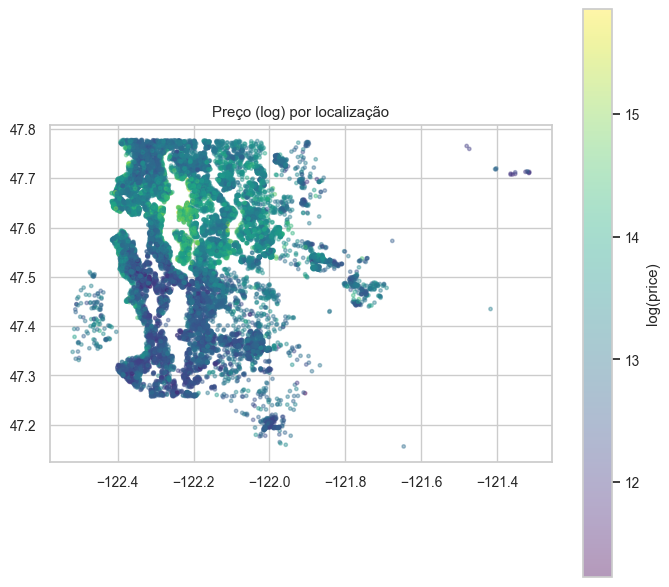

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(casas["long"], casas["lat"], c=casas["log_price"], cmap="viridis", alpha=0.4, s=6)
ax.set_aspect(1.3)
plt.colorbar(sc, label="log(price)")
ax.set_title("Preço (log) por localização")
plt.tight_layout()
plt.show()

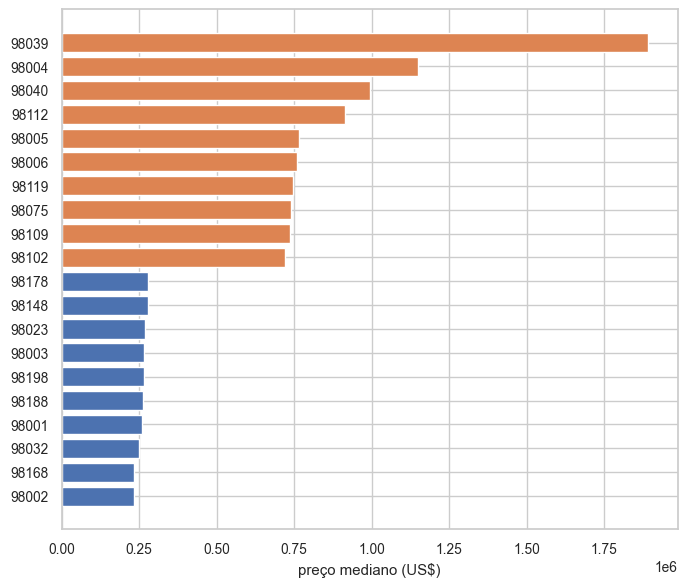

In [22]:
preco_zip = casas.groupby("zipcode")["price"].median().sort_values()
extremos = pd.concat([preco_zip.head(10), preco_zip.tail(10)])
grupo = ["10 CEPs mais baratos"] * 10 + ["10 CEPs mais caros"] * 10

fig, ax = plt.subplots(figsize=(7, 6))
cores = {"10 CEPs mais baratos": "#4C72B0", "10 CEPs mais caros": "#DD8452"}
ax.barh(extremos.index.astype(str), extremos.values, color=[cores[g] for g in grupo])
ax.set_xlabel("preço mediano (US$)")
plt.tight_layout()
plt.show()

A localização é visivelmente um dos fatores mais fortes: há um gradiente geográfico claro (região central/leste do lago, mais cara), e a diferença de preço mediano entre o CEP mais caro (98039, US\$ 1.892.500) e o mais barato (98002, US\$ 235.000) chega a **8×**. Isso reforça manter `lat`/`long` (ou `zipcode`) como preditores, além de já sinalizar por que os dados demográficos por CEP tendem a ser informativos.

## 10. Dados demográficos por CEP

In [23]:
vars_demograf_todas = [c for c in demograf.columns if c != "zipcode"]
tabela_demograf = tabela_descritiva(demograf, vars_demograf_todas)
tabela_demograf

,variavel,n,ausentes,pct_ausente,media,mediana,moda,dp,variancia,amplitude,iqr,cv_pct,assimetria,curtose,minimo,q1,q3,maximo
0,sbrbn_ppltn_qty,70,0,0.00,192.46,0.00,0.00,"1,359.78","1,849,011.73","11,176.00",0.00,706.54,7.74,59.67,0.00,0.00,0.00,"11,176.00"
1,per_sbrbn,70,0,0.00,2.03,0.00,0.00,12.03,144.84,81.00,0.00,593.27,5.84,32.74,0.00,0.00,0.00,81.00
2,farm_ppltn_qty,70,0,0.00,16.44,0.00,0.00,59.57,"3,548.22",439.00,0.00,362.27,5.53,34.83,0.00,0.00,0.00,439.00
3,per_farm,70,0,0.00,0.10,0.00,0.00,0.39,0.15,2.00,0.00,386.36,4.01,15.50,0.00,0.00,0.00,2.00
4,per_non_farm,70,0,0.00,7.01,0.00,0.00,19.56,382.51,98.00,0.75,278.83,3.54,12.44,0.00,0.00,0.75,98.00
5,per_urbn,70,0,0.00,90.49,100.00,100.00,25.15,632.69,100.00,1.75,27.80,-2.97,7.53,0.00,98.25,100.00,100.00
6,non_farm_qty,70,0,0.00,866.61,0.00,0.00,"2,007.03","4,028,162.10","9,973.00",313.00,231.59,2.88,8.50,0.00,0.00,313.00,"9,973.00"
7,hous_val_amt,70,0,0.00,"263,954.29","239,850.00","239,850.00","107,660.17","11,590,711,937.89","648,800.00","95,700.00",40.79,2.26,7.27,"141,500.00","193,225.00","288,925.00","790,300.00"
8,edctn_less_than_9_qty,70,0,0.00,633.61,406.00,406.00,653.26,"426,748.53","3,667.00",699.75,103.10,2.21,6.07,4.00,200.00,899.75,"3,671.00"
9,medn_incm_per_prsn_amt,70,0,0.00,"30,623.34","27,639.50","27,639.50","10,256.97","105,205,503.72","64,839.00","10,785.25",33.49,2.15,7.48,"17,087.00","24,422.00","35,207.25","81,926.00"


Mesma função de estatística descritiva da seção 2, aplicada aqui aos dados demográficos, pra manter o mesmo padrão de rigor. Vale notar que essa tabela é sobre **70 CEPs**, não sobre os 21.613 imóveis — cada linha descreve a variação *entre bairros*, não entre casas.

Dois grupos bem diferentes de comportamento, e não é o que eu esperava de cara: os percentuais de **escolaridade** (`per_hsd`, `per_bchlr`, `per_some_clg`, `per_assoc`, `per_prfsnl`) são bem comportados, com assimetria baixa (entre -0,68 e 1,21). Já `per_urbn`, `per_sbrbn`, `per_farm` e `per_non_farm` estão entre as variáveis **mais assimétricas de toda a tabela** (`per_sbrbn` chega a 5,84, `per_urbn` a -2,97): a mediana de `per_urbn` é 100% — a grande maioria dos CEPs de King County no dataset é essencialmente 100% urbana, e só uma minoria tem qualquer população suburbana/rural. É o mesmo padrão "quase binário disfarçado de contínuo" que já vi em `yr_renovated` na seção 2, só que aqui no nível de CEP em vez de imóvel individual. As variáveis de renda em dólar ficam num meio-termo, com assimetria moderada (1,75 a 2,26) — puxada por alguns CEPs residenciais de renda bem mais alta que a maioria.

In [24]:
casas_full = casas.merge(demograf, on="zipcode", how="left")

vars_demograf = ["medn_hshld_incm_amt", "medn_incm_per_prsn_amt", "hous_val_amt",
                  "per_hsd", "per_some_clg", "per_bchlr", "per_prfsnl"]

casas_full[vars_demograf].corrwith(casas_full["log_price"]).sort_values(key=lambda s: s.abs(), ascending=False)

hous_val_amt              0.63
per_hsd                  -0.62
per_bchlr                 0.61
medn_incm_per_prsn_amt    0.61
per_prfsnl                0.60
medn_hshld_incm_amt       0.31
per_some_clg             -0.21
dtype: float64

`hous_val_amt` (valor médio dos imóveis no CEP, correlação 0,63) e `medn_incm_per_prsn_amt` (renda mediana per capita, 0,61) aparecem com correlação positiva relevante com `log_price`, assim como `per_bchlr`/`per_prfsnl` (% com ensino superior, ~0,6). `per_hsd` (% só com ensino médio) tem correlação **negativa** de magnitude parecida (-0,62) — leitura espelhada da mesma coisa: quanto maior a % de escolaridade só até o ensino médio no CEP, menor o preço mediano. Não é surpresa — reforça que os dados demográficos agregam informação além das características físicas do imóvel.

Uma ressalva que preciso deixar clara: os dados demográficos são agregados por CEP e ficam **idênticos para todos os imóveis do mesmo zipcode** depois do merge — ou seja, eles não explicam variação *dentro* de um CEP, só variação *entre* CEPs. A correlação acima mistura os dois níveis (imóvel e CEP), o que é uma leitura ecológica: um CEP mais rico tende a ter imóveis mais caros em média, mas isso não implica que a renda "causa" o preço no nível do imóvel individual. Na modelagem, é preciso ter cuidado ao interpretar a importância dessas variáveis, porque o efeito delas fica parcialmente confundido com `zipcode`/`lat`/`long`.

## 11. Consistência com `future_unseen_examples.csv`

In [25]:
vars_comuns = [c for c in casas.columns if c in futuro.columns and c != "zipcode"]

comparacao = pd.DataFrame({
    "min_treino": casas[vars_comuns].min(),
    "max_treino": casas[vars_comuns].max(),
    "min_futuro": futuro[vars_comuns].min(),
    "max_futuro": futuro[vars_comuns].max(),
})
comparacao

,min_treino,max_treino,min_futuro,max_futuro
bedrooms,0.00,33.00,2.00,6.00
bathrooms,0.00,8.00,1.00,4.50
sqft_living,290.00,"13,540.00",750.00,"4,580.00"
sqft_lot,520.00,"1,651,359.00","1,194.00","214,750.00"
floors,1.00,3.50,1.00,3.00
waterfront,0.00,1.00,0.00,1.00
view,0.00,4.00,0.00,4.00
condition,1.00,5.00,3.00,5.00
grade,1.00,13.00,5.00,10.00
sqft_above,290.00,"9,410.00",750.00,"4,580.00"


Os valores de `future_unseen_examples.csv` estão dentro (ou muito próximos) do intervalo que observei no treino para todas as variáveis — a única exceção de nota é `bedrooms`, onde o treino vai até 33 (o erro de digitação da seção 4) e o futuro vai só até 6, o que é esperado já que excluí o outlier do "intervalo válido" de comparação. Fora isso, não vejo indício de *covariate shift* grosseiro que exigiria cuidado extra de extrapolação do modelo.

## 12. O que levo desta análise para a modelagem

- Uso `log(price)` como target, revertendo com `exp()` na hora de reportar previsões em dólares — a distribuição bruta é assimétrica demais (skew 4,02) para um modelo linear se comportar bem.
- Preciso tratar/excluir o registro de 33 quartos antes de treinar qualquer coisa; é erro de digitação, não informação real.
- Por causa da redundância `sqft_living = sqft_above + sqft_basement` (VIF infinito quando as três entram juntas), não uso as três ao mesmo tempo como preditoras — fico com `sqft_living` e uma flag binária de porão (`tem_porao`).
- Os preditores que mais se destacaram isoladamente foram `grade`, `sqft_living`, `sqft_living15` e a localização (`lat`/`long`/`zipcode`).
- As variáveis ordinais/categóricas (`waterfront`, `view`, `condition`, `grade`) mostraram diferença significativa de preço entre níveis no Kruskal-Wallis, então pretendo mantê-las todas como preditoras — mas com atenção aos níveis de `grade` com poucas observações (n=1 em `grade=1`, n=3 em `grade=3`).
- Localização parece ser um driver forte e não-linear (razão de 8× entre CEP mais caro e mais barato) — `lat`/`long` brutos num modelo linear provavelmente vão underperform; modelos baseados em árvore devem capturar melhor esse padrão.
- Os dados demográficos agregam informação, mas com efeito confundido com localização (a ressalva ecológica da seção 10) — vale comparar o modelo com e sem essas variáveis para medir o ganho incremental real.
- Não há valores ausentes nem *covariate shift* aparente entre treino e `future_unseen_examples.csv`, então não é preciso tratamento especial de missing/extrapolação nessa etapa.

Todas essas decisões batem com as que já tinha tomado na versão R (`analysis/01_eda.qmd`) — reforça que a escolha de feature engineering usada a partir daqui em [`02-1_modelagem.ipynb`](02-1_modelagem.ipynb) não depende de qual das duas implementações eu tivesse usado para a EDA.